# Modelling

In [2]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from logitplots import plt_confusion_matrix, plt_decision_boundaries, plt_correlation_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

# import data
data = pd.read_csv("/Users/jiehni/monash/ADS2001_GROUPMC3/data/processed/melb.csv")
data.head()

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),...,WindDir_NNW,WindDir_NW,WindDir_S,WindDir_SE,WindDir_SSE,WindDir_SSW,WindDir_SW,WindDir_W,WindDir_WNW,WindDir_WSW
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,11,...,False,False,False,True,False,False,False,False,False,False
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,11,...,False,False,False,True,False,False,False,False,False,False
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,11,...,False,False,False,True,False,False,False,False,False,False
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,11,...,False,False,False,True,False,False,False,False,False,False
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,9,...,False,False,False,False,False,False,False,False,False,False


### Decision Tree for Level of Rain

Decision Tree Level of Rain (no rain: 0mm, light rain: 0-2mm, moderate rain: 2-10mm, heavy rain: 10-50mm, extreme rain: 50+mm) – Jiehni

In [3]:
# create bins for rain level
data["Rainfall Band"] = pd.cut(
    data["Rainfall since 9 am (mm)"],
    bins=[-0.1, 0, 2, 10, 50, np.inf],
    labels=["No Rain", "Light", "Medium", "Heavy", "Extreme"]
)

# select variables
X = data.drop(["Rainfall since 9 am (mm)", "Rainfall Band", "Rain", "Datetime"], axis=1)
y = data["Rainfall Band"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

In [4]:
print(data["Rainfall Band"].value_counts())

Rainfall Band
No Rain    245274
Light       51625
Medium      25153
Heavy        7591
Extreme         4
Name: count, dtype: int64


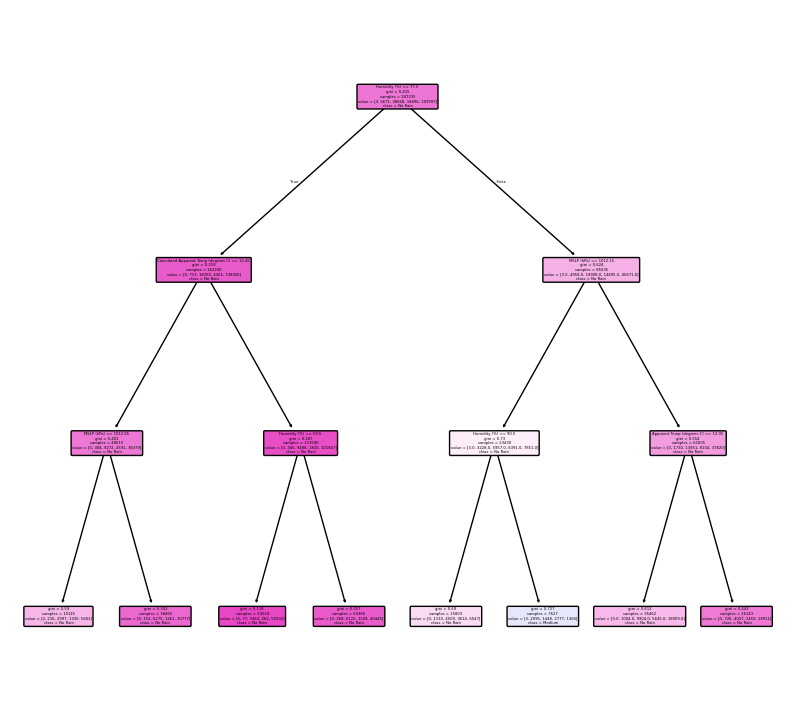

In [6]:
data_dtc = DecisionTreeClassifier(
    random_state = 42, 
    min_samples_split=10,
    max_depth=3) 

data_dtc = data_dtc.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 9))
plot_tree(
    data_dtc,
    filled=True,
    rounded=True,
    class_names=data_dtc.classes_,
    feature_names=X.columns,
    ax=ax
)
plt.show()

In [7]:
# feature importance
importance = pd.Series(data_dtc.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

Humidity (%)                            0.650409
MSLP (hPa)                              0.195644
Calculated Apparent Temp (degrees C)    0.090397
Apparent Temp (degrees C)               0.063550
Year                                    0.000000
WindDir_S                               0.000000
WindDir_NE                              0.000000
WindDir_NNE                             0.000000
WindDir_NNW                             0.000000
WindDir_NW                              0.000000
WindDir_SE                              0.000000
WindDir_ESE                             0.000000
WindDir_SSE                             0.000000
WindDir_SSW                             0.000000
WindDir_SW                              0.000000
WindDir_W                               0.000000
WindDir_WNW                             0.000000
WindDir_N                               0.000000
WindDir_CALM                            0.000000
WindDir_ENE                             0.000000
WindDir_E           

Most important features are Humidity (%), MSLP (hPa), Calculated Apparent Temp (degrees C) and Apparent Temp (degrees C).

Decision Tree Accuracy: 0.75


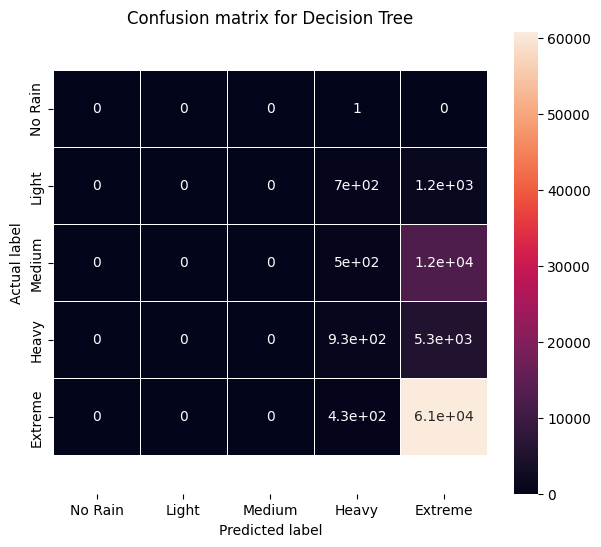

In [8]:
Y_pred = data_dtc.predict(X_test)
cm = confusion_matrix(y_test, Y_pred)
plt_confusion_matrix(cm, ["No Rain", "Light", "Medium", "Heavy", "Extreme"], "Decision Tree") 
print("Decision Tree Accuracy:",np.round(accuracy_score(y_test, Y_pred),3))

In [9]:
print(classification_report(y_test, Y_pred))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

     Extreme       0.00      0.00      0.00         1
       Heavy       0.00      0.00      0.00      1920
       Light       0.00      0.00      0.00     12957
      Medium       0.36      0.15      0.21      6257
     No Rain       0.76      0.99      0.86     61277

    accuracy                           0.75     82412
   macro avg       0.23      0.23      0.21     82412
weighted avg       0.59      0.75      0.66     82412



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The dataset has severe class imbalance with majority of observations belonging to the "No Rain" class and only 4 "Extreme" rainfall events. As a result, the decision tree model is highly biased to the majority classes as shown by the low recall and f1 scores.

Hence, accuracy alone is not a reliable metric and the class imbalance must be addressed to improve the model's performance. To combat this we will reduce the number of classes and remove "Extreme" class. 

In [20]:
# reduce number of classes
data["Rainfall Band"] = pd.cut(
    data["Rainfall since 9 am (mm)"],
    bins=[-0.1, 0, 5, 20, np.inf],
    labels=["No Rain", "Light", "Medium", "Heavy"]
)

# select variables
X = data.drop(["Rainfall since 9 am (mm)", "Rainfall Band", "Rain", "Datetime"], axis=1)
y = data["Rainfall Band"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

In [21]:
print(data["Rainfall Band"].value_counts())

Rainfall Band
No Rain    245274
Light       67670
Medium      14273
Heavy        2430
Name: count, dtype: int64


This distribution is more even compared to before

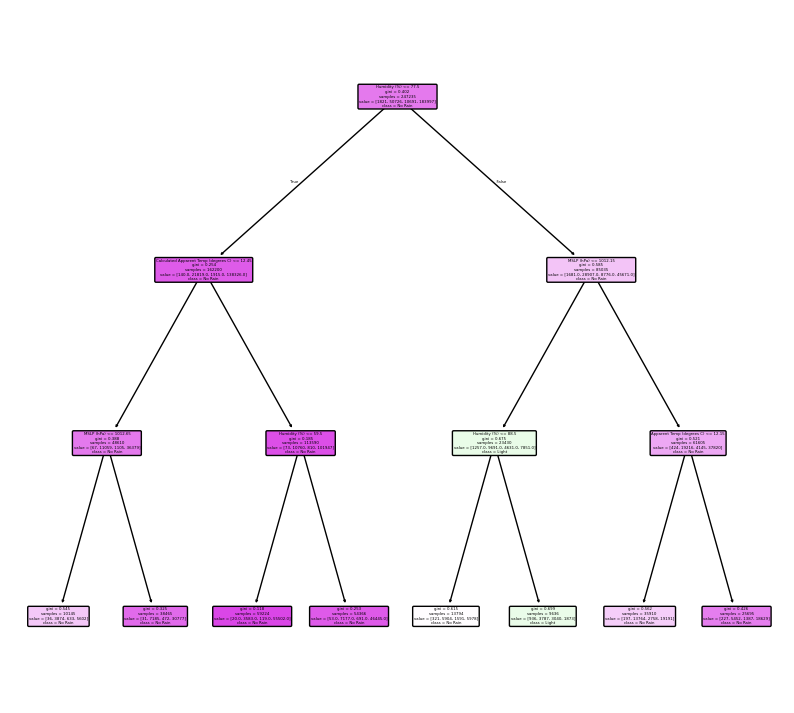

In [22]:
data_dtc = DecisionTreeClassifier(
    random_state = 42, 
    min_samples_split=10,
    max_depth=3) 

data_dtc = data_dtc.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 9))
plot_tree(
    data_dtc,
    filled=True,
    rounded=True,
    class_names=data_dtc.classes_,
    feature_names=X.columns,
    ax=ax
)
plt.show()

Decision Tree Accuracy: 0.752


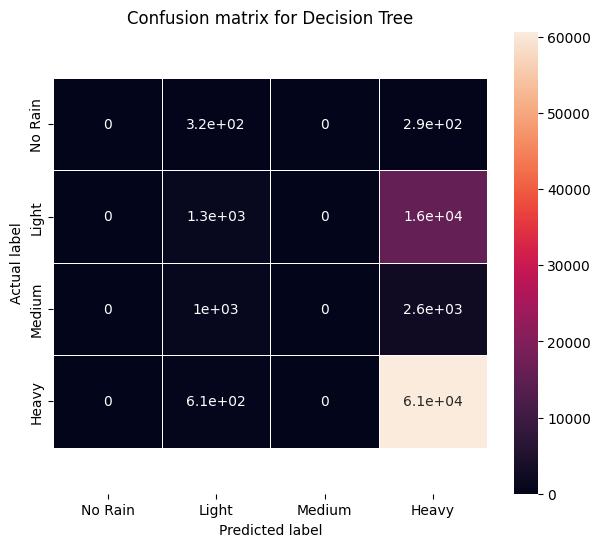

In [23]:
Y_pred = data_dtc.predict(X_test)
cm = confusion_matrix(y_test, Y_pred)
plt_confusion_matrix(cm, ["No Rain", "Light", "Medium", "Heavy"], "Decision Tree") 
print("Decision Tree Accuracy:",np.round(accuracy_score(y_test, Y_pred),3))

In [24]:
labels = ["No Rain", "Light", "Medium", "Heavy"]

print(classification_report(y_test, Y_pred, labels=labels))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

     No Rain       0.77      0.99      0.86     61277
       Light       0.40      0.08      0.13     16944
      Medium       0.00      0.00      0.00      3582
       Heavy       0.00      0.00      0.00       609

    accuracy                           0.75     82412
   macro avg       0.29      0.27      0.25     82412
weighted avg       0.65      0.75      0.67     82412



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Reducing the number of rainfall categories improved model performance as it reduced class imbalance and increased the number of samples per class. The model's accuracy has improved by 0.02 but is still performing poorly, especially for "Medium" and "Heavy" rainfall bands which are not being predicted at all.

To continue to improve this model we trialled class balancing.

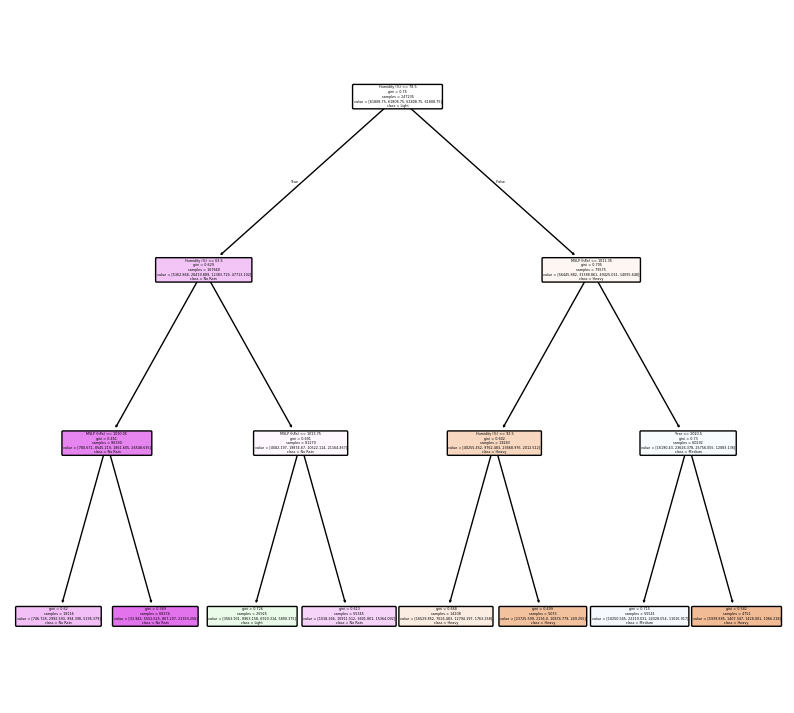

In [25]:
# balance classes
data_dtc_balanced = DecisionTreeClassifier(
    random_state = 42, 
    min_samples_split=10,
    max_depth=3,
    class_weight="balanced") 

data_dtc_balanced = data_dtc_balanced.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 9))
plot_tree(
    data_dtc_balanced,
    filled=True,
    rounded=True,
    class_names=data_dtc_balanced.classes_,
    feature_names=X.columns,
    ax=ax
)
plt.show()

Decision Tree Accuracy: 0.557


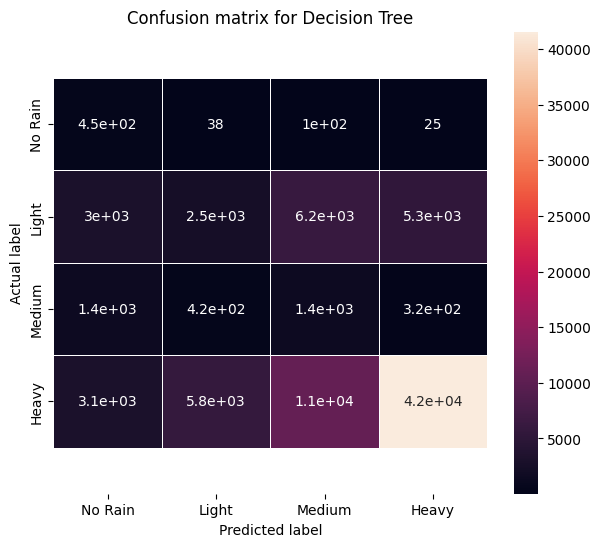

In [26]:
Y_pred_balanced = data_dtc_balanced.predict(X_test)
cm = confusion_matrix(y_test, Y_pred_balanced)
plt_confusion_matrix(cm, ["No Rain", "Light", "Medium", "Heavy"], "Decision Tree") 
print("Decision Tree Accuracy:",np.round(accuracy_score(y_test, Y_pred_balanced),3))

In [27]:
labels = ["No Rain", "Light", "Medium", "Heavy"]

print(classification_report(y_test, Y_pred_balanced, labels=labels))

              precision    recall  f1-score   support

     No Rain       0.88      0.68      0.77     61277
       Light       0.28      0.14      0.19     16944
      Medium       0.08      0.39      0.13      3582
       Heavy       0.06      0.73      0.10       609

    accuracy                           0.56     82412
   macro avg       0.32      0.49      0.30     82412
weighted avg       0.72      0.56      0.62     82412



Applying class weighting improved the model’s ability to detect minority classes such as heavy rainfall but overall performance remained limited due to the severe class imbalance. 

The model’s accuracy decreased to 0.552 after class balancing as it attempted to better predict minority classes. Performance improved for "Heavy" and "Medium". Class weighting helped to reduce bias but it cannot fully compensate for insufficient data in rare categories.

Although several features showed zero importance in the decision tree model, removing these features resulted in a decrease in classification performance. This suggests that while their individual contribution appears minimal, they may still provide useful information in combination with other features. Therefore, all features were retained in the final model to preserve predictive performance